# **DP bedload model in 2d**

<hr>

## Preliminaries

In [281]:
from essentials import *
dprs.__version__

'2026.4.21'

In [282]:
viz = Viz(dpi=125)

<hr>

## Parameters

In [283]:
n_xy: int = 300
n_iterations: int = 5000
# p_conj = 0

In [284]:
# phase_diagram_expts_tuple = (
#     dict(p_1=0.5383, p_2=0.9990,   p_conj=0, scale=1.26),
#     dict(p_1=0.5391, p_2=0.9900,   p_conj=0, scale=1.26),
#     dict(p_1=0.5497, p_2=0.8500,   p_conj=0, scale=1.15),
#     dict(p_1=0.5594, p_2=0.7000,   p_conj=0, scale=0.98),
#     dict(p_1=0.5671, p_2=0.5671,   p_conj=0, scale=0.925),
#     dict(p_1=0.5708, p_2=0.5000,   p_conj=0, scale=0.89),
#     dict(p_1=0.5806, p_2=0.3000,   p_conj=0, scale=0.81),
#     dict(p_1=0.5873, p_2=0.1500,   p_conj=0, scale=0.76),
#     dict(p_1=0.5934, p_2=0.0000,   p_conj=0, scale=0.725),
# )
# phase_diagram_expts = {i: expt for i, expt in enumerate(phase_diagram_expts_tuple)}

In [ ]:
phase_diagram_expts_tuple = (
    # dict(p_1=0.5400, p_2=1, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.539, p_2=0.99, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.5530, p_2=0.8, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.5653, p_2=0.6, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.567, p_2=0.567, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.5755, p_2=0.4, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.5840, p_2=0.2, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
    dict(p_1=0.5934, p_2=0.0, p_conj=0, p_nbr=0, scale=0.25, tail_mean_ρ=0),
)
phase_diagram_expts = {i: expt for i, expt in enumerate(phase_diagram_expts_tuple)}

In [328]:
percolation_expts_tuple = (
    # dict(p_1=0.5935, p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=3.985063e-03),
    dict(p_1=0.5936, p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=1.192684e-02),
    dict(p_1=0.5937, p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=1.512679e-02),
    dict(p_1=0.594,  p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=2.308059e-02),
    dict(p_1=0.595,  p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=4.063054e-02),
    dict(p_1=0.597,  p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=6.589431e-02),
    dict(p_1=0.6,    p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=9.406315e-02),
    dict(p_1=0.61,   p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=1.603259e-01),
    dict(p_1=0.62,   p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=2.102596e-01),
    dict(p_1=0.65,   p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=3.240914e-01),
    dict(p_1=0.7,    p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=4.655104e-01),
    dict(p_1=0.75,   p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=5.800711e-01),
    dict(p_1=0.8,    p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=6.797910e-01),
    dict(p_1=0.85,   p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=7.695162e-01),
    dict(p_1=0.9,    p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=8.518297e-01),
    dict(p_1=0.95,   p_2=0.0000,   p_conj=0, scale=0.725, tail_mean_ρ=9.283094e-01),
)

In [329]:
p3_expts_tuple = (
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=1.276744e-06),
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=1.156416e-05),
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=1.229950e-04),
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=1.202141e-03),
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=1.141549e-02),
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=8.502819e-02),
    dict(p_1=0.5, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=3.411415e-01),
    #
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=3.936034e-06),
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=3.608598e-05),
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=3.767733e-04),
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=3.666900e-03),
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=3.063740e-02),
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=1.442286e-01),
    dict(p_1=0.55, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=3.977777e-01),
    # 
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=1.504738e-05),
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=1.306045e-04),
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=1.339584e-03),
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=1.231168e-02),
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=6.619371e-02),
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=1.900987e-01),
    dict(p_1=0.575, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.286503e-01),
    # 
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=5.387214e-05),
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=4.282526e-04),
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=4.508136e-03),
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=2.879759e-02),
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=9.332287e-02),
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.114318e-01),
    dict(p_1=0.585, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.414231e-01),
    # 
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=2.712881e-04),
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=1.758293e-03),
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=1.318895e-02),
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=4.751823e-02),
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=1.099126e-01),
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.226105e-01),
    dict(p_1=0.59, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.479314e-01),
    # 
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=1.367268e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=2.087483e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=3.487083e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=6.552066e-02),
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=1.220608e-01),
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.303522e-01),
    dict(p_1=0.5934, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.523607e-01),
    # 
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=6.611606e-02),
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=6.656436e-02),
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=7.004081e-02),
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=8.804800e-02),
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=1.362778e-01),
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.388846e-01),
    dict(p_1=0.597, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.570666e-01),
    # 
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=9.480e-02),
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=9.500e-02),
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=9.620e-02),
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=1.069e-01),
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=1.476e-01),
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.458e-01),
    dict(p_1=0.6, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.610e-01),
    # 
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=1.603634e-01),
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=1.604069e-01),
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=1.607907e-01),
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=1.643766e-01),
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=1.877898e-01),
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.700789e-01),
    dict(p_1=0.61, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.742828e-01),
    # 
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=2.102540e-01),
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=2.102743e-01),
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=2.104702e-01),
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=2.122575e-01),
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=2.268593e-01),
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=2.947867e-01),
    dict(p_1=0.62, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=4.877410e-01),
    # 
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-7, scale=0.725, tail_mean_ρ=3.240246e-01),
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-6, scale=0.725, tail_mean_ρ=3.240299e-01),
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-5, scale=0.725, tail_mean_ρ=3.240843e-01),
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-4, scale=0.725, tail_mean_ρ=3.246521e-01),
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-3, scale=0.725, tail_mean_ρ=3.300569e-01),
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-2, scale=0.725, tail_mean_ρ=3.693711e-01),
    dict(p_1=0.65, p_2=0.0000,   p_conj=1e-1, scale=0.725, tail_mean_ρ=5.289810e-01),
)

In [330]:
speed_expts_tuple = (
    dict(p_1=0.45,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=0),
    dict(p_1=0.47,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=0),
    dict(p_1=0.55,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=0),
    dict(p_1=0.5933, p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=0),
    dict(p_1=0.5936, p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=1.192684e-02),
    dict(p_1=0.5937, p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=1.512679e-02),
    dict(p_1=0.594,  p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=2.308059e-02),
    dict(p_1=0.595,  p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=4.063054e-02),
    dict(p_1=0.597,  p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=6.589431e-02),
    dict(p_1=0.6,    p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=9.406315e-02),
    dict(p_1=0.61,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=1.603259e-01),
    dict(p_1=0.62,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=2.102596e-01),
    dict(p_1=0.65,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=3.240914e-01),
    dict(p_1=0.7,    p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=4.655104e-01),
    dict(p_1=0.75,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=5.800711e-01),
    dict(p_1=0.8,    p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=6.797910e-01),
    dict(p_1=0.85,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=7.695162e-01),
    dict(p_1=0.9,    p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=8.518297e-01),
    dict(p_1=0.95,   p_2=0.0,   p_conj=0, scale=0.725, tail_mean_ρ=9.283094e-01),
)
n_y = None
seed = 6

In [331]:
grouped_by_speed_expts = {
    expt["p_1"]: expt for i, expt in enumerate(speed_expts_tuple)
}
grouped_by_percolation_expts = {
    expt["p_1"]: expt for i, expt in enumerate(percolation_expts_tuple)
}

grouped_by_p1_expts = {expt["p_1"]: {} for i, expt in enumerate(p3_expts_tuple)}
for i, expt in enumerate(p3_expts_tuple):
    grouped_by_p1_expts[expt["p_1"]].update({expt["p_conj"]: expt})
grouped_by_p3_expts = {expt["p_conj"]: {} for i, expt in enumerate(p3_expts_tuple)}

for i, expt in enumerate(p3_expts_tuple):
    grouped_by_p3_expts[expt["p_conj"]].update({expt["p_1"]: expt})

In [332]:
class Parameters:
    growth_model = GrowthModel.BedloadB
    dim = Dimension.D2
    n_x: int = n_xy
    n_y: int = n_xy if n_y is None else n_y
    n_z: int = 1
    p_1: float = expt["p_1"]
    p_2: float = expt["p_2"]
    p_conj: float = expt["p_conj"]
    p_nbr: float = 0.5
    p_diag: float = 0.5
    n_iterations: int = n_iterations
    sample_period: int = 0
    random_seed: int = seed if seed is not None else 1
    # initial_condition = InitialCondition.CentralCell
    # initial_condition = InitialCondition.EdgeCell
    initial_condition = InitialCondition.Randomized
    p_initial: float = 0.1
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()

In [314]:
sim.print(parameters)

Growth model:  BedloadB
Dimension:     D2
Grid shape:    (300, 300, 1)
Prob. p_1:     0.65
Prob. p_2:     0
Prob. p_conj:  0.1
Prob. p_nbr:   0.5
Prob. p_diag:  0.5
Iterations:    5000
Sample period: 0
Random seed:   6
Initial cond.: Randomized
Initial prob.: 0.1
Topology x:    Periodic
Topology y:    Periodic
Topology z:    Unspecified
Axis BCs x:    (Floating, Floating)
Axis BCs y:    (Floating, Floating)
Axis BCs z:    (Unspecified, Unspecified)
BC values x:   (true, true)
BC values y:   (true, true)
BC values z:   (false, false)
Edge buffer:   true
Processing:    Parallel
Num. threads:  16



<hr>

## Simulation

In [315]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [316]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [317]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

In [318]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(0,)

<hr>

## Visualization

### Phase diagram

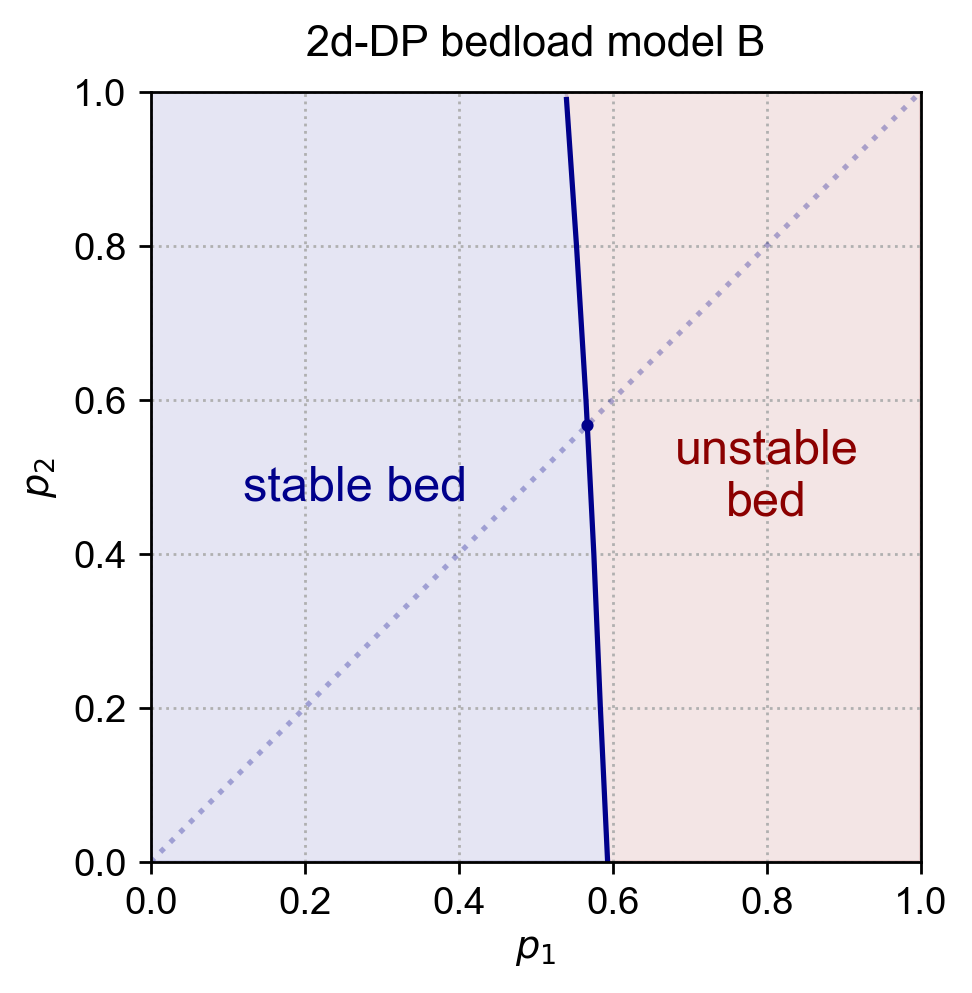

In [333]:
name: str = make_name(parameters, "phase_diagram",)
title: str = "2d-DP bedload model B"
viz.phase_diagram(name, title, parameters, phase_diagram_expts, i_equal=3,)
plt.show()

### Dependence on external field $p_\mathsf{conj}$

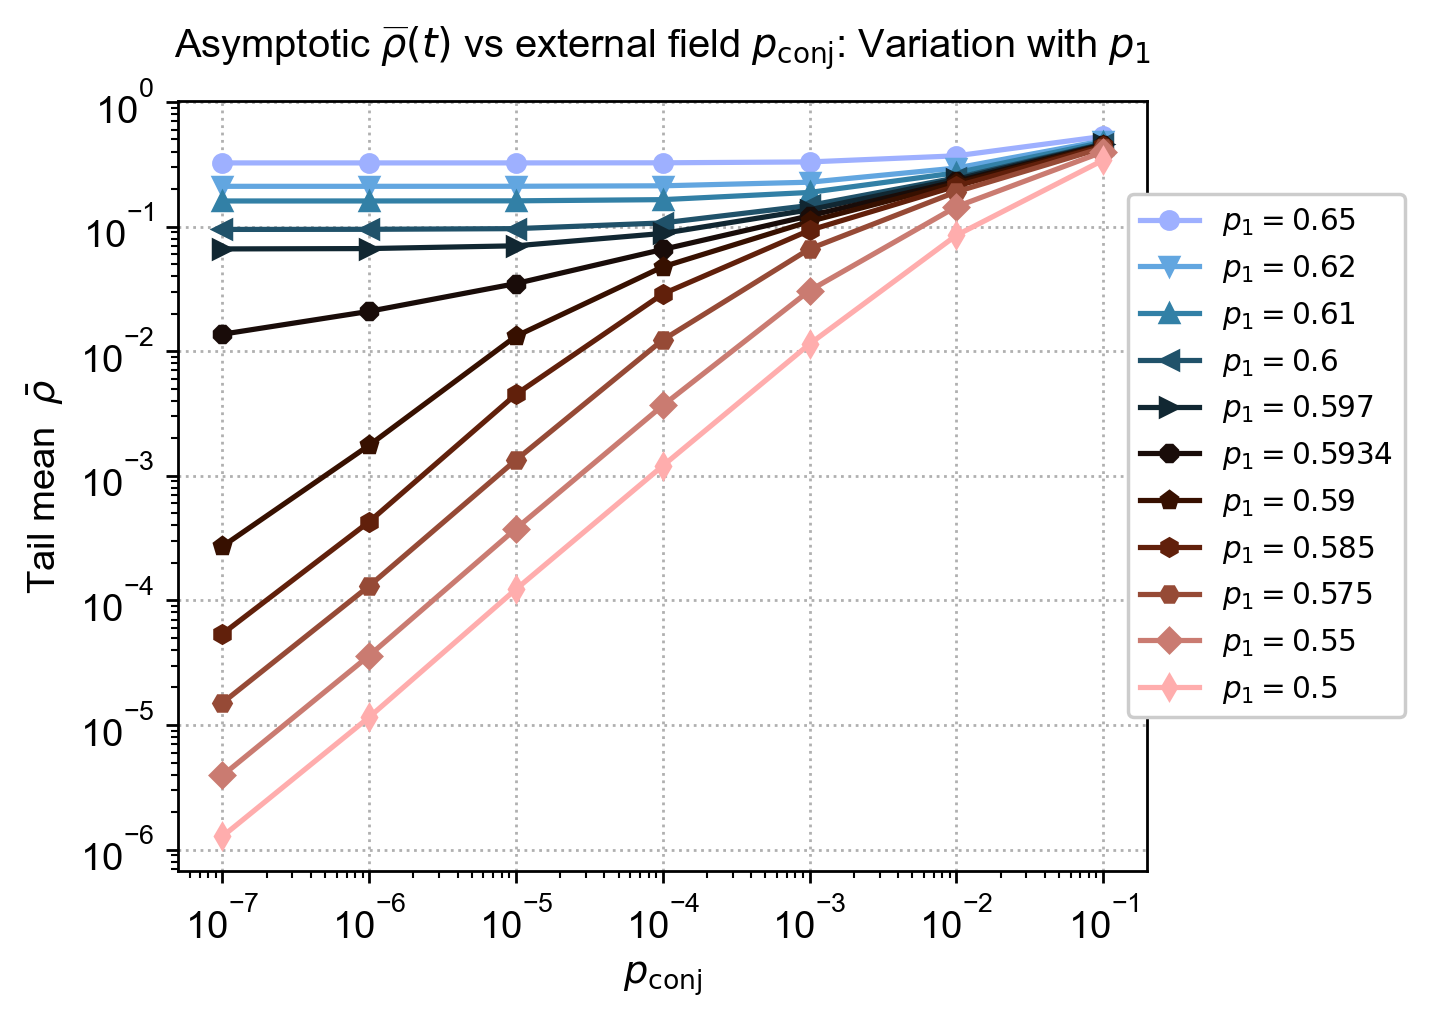

In [297]:
viz.create_figure(fig_name="", fig_size=(5, 4,),)
plt.title(
    "Asymptotic $\\widebar\\rho(t)$ vs external field $p_\mathsf{conj}$: "
        + "Variation with $p_1$", 
    fontdict={"fontsize": 11.5}, y=1.03,
)
p_1_choices = (0.5, 0.55, 0.575, 0.585, 0.59, 0.5934, 0.597, 0.6, 0.61, 0.62, 0.65,)
# color_map_name = "copper_r"
# color_map_name = "winter"
color_map_name = "coolwarm"
color_map_name = "berlin"
# color_map_name = "managua"
color_map = plt.get_cmap(color_map_name)
colors = color_map(np.linspace(0, 1, len(p_1_choices)))
for (p_1, color, marker) in zip(reversed(p_1_choices), colors, viz.markers.keys()):
    xy = np.array([
        (v["p_conj"], v["tail_mean_ρ"]) 
        for v in grouped_by_p1_expts[p_1].values()
    ]).T
    plt.plot(
        *xy, marker=marker, ms=5, color=color, label=rf"$p_1={p_1}$"
    )
# plt.xlim(0, 1,)
# plt.ylim(0, 1,)
plt.xlabel(r"$p_\mathsf{conj}$")
plt.ylabel(r"Tail mean  $\bar{\rho}$")
# axes = plt.gca()
# axes.set_aspect(1)
plt.semilogx()
plt.loglog()
plt.legend(fontsize=8.5, loc=(0.98, 0.2,), framealpha=1)
plt.grid(ls=":")

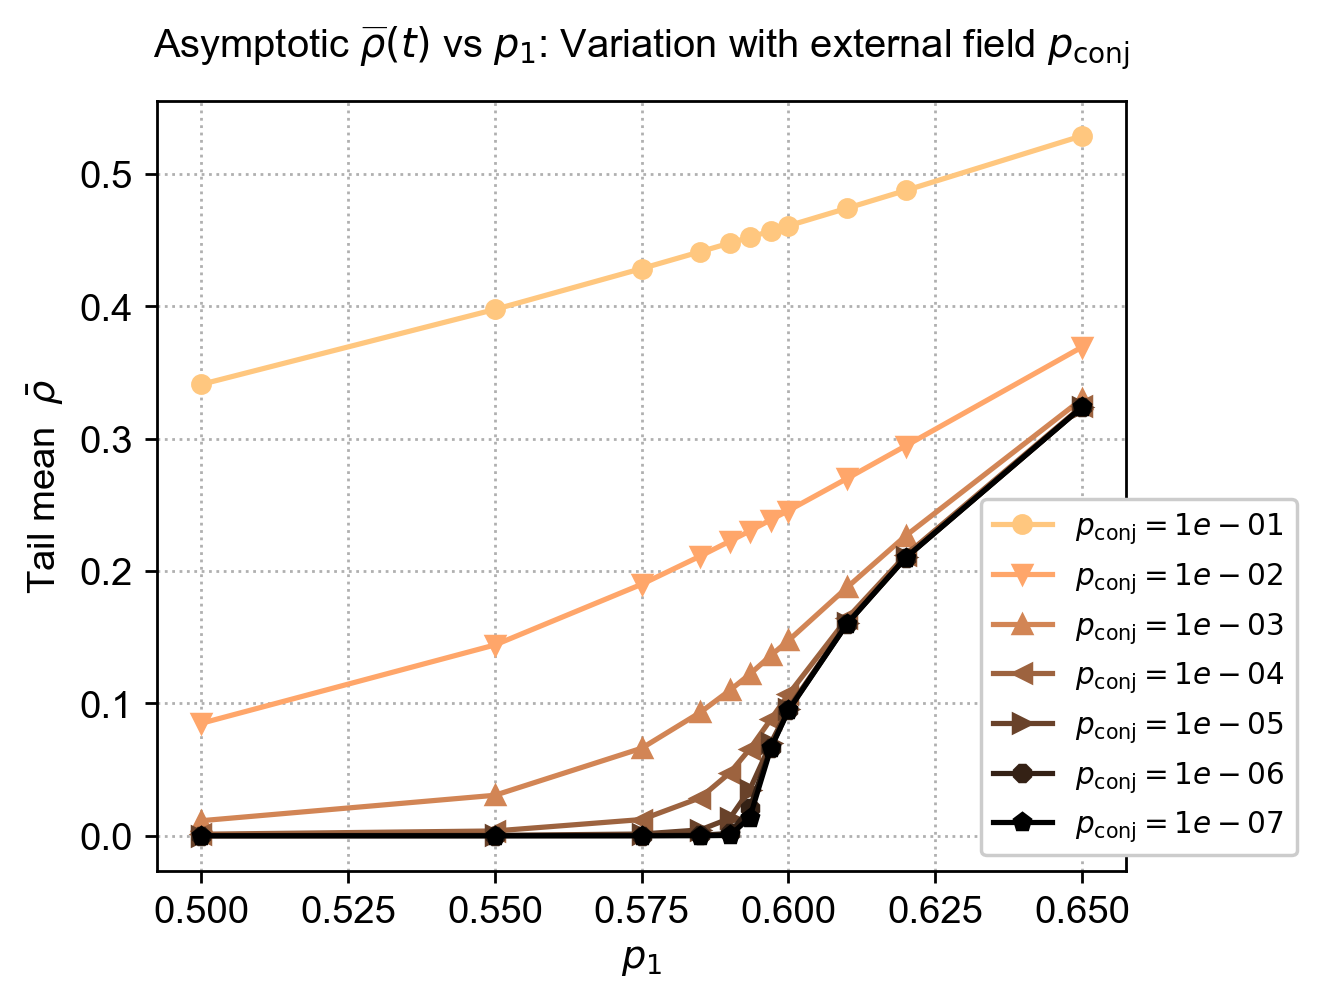

In [298]:
viz.create_figure(fig_name="", fig_size=(5, 4,),)
plt.title(
    "Asymptotic $\\widebar\\rho(t)$ vs $p_1$: "
        + "Variation with external field $p_\\mathsf{conj}$", 
    fontdict={"fontsize": 11.5}, y=1.03,
)
p_conj_choices = (1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,)
color_map_name = "copper_r"
# color_map_name = "winter"
# color_map_name = "coolwarm"
# color_map_name = "berlin"
# color_map_name = "managua"
color_map = plt.get_cmap(color_map_name)
colors = color_map(np.linspace(0, 1, len(p_conj_choices)))
for (p_conj, color, marker) in zip(reversed(p_conj_choices), colors, viz.markers.keys()):
    xy = np.array([
        (v["p_1"], v["tail_mean_ρ"]) for v in grouped_by_p3_expts[p_conj].values()
    ]).T
    plt.plot(
        *xy, marker=marker, ms=5, color=color, 
        label=r"$p_\mathsf{conj}=$"+rf"${p_conj:0.0e}$"
    )
# plt.xlim(0, 1,)
# plt.ylim(0, 1,)
plt.xlabel(r"$p_1$")
plt.ylabel(r"Tail mean  $\bar{\rho}$")
# axes = plt.gca()
# axes.set_aspect(1)
# plt.semilogx()
# plt.loglog()
plt.legend(fontsize=8.5, loc=(0.85, 0.02,), framealpha=1)
plt.grid(ls=":")

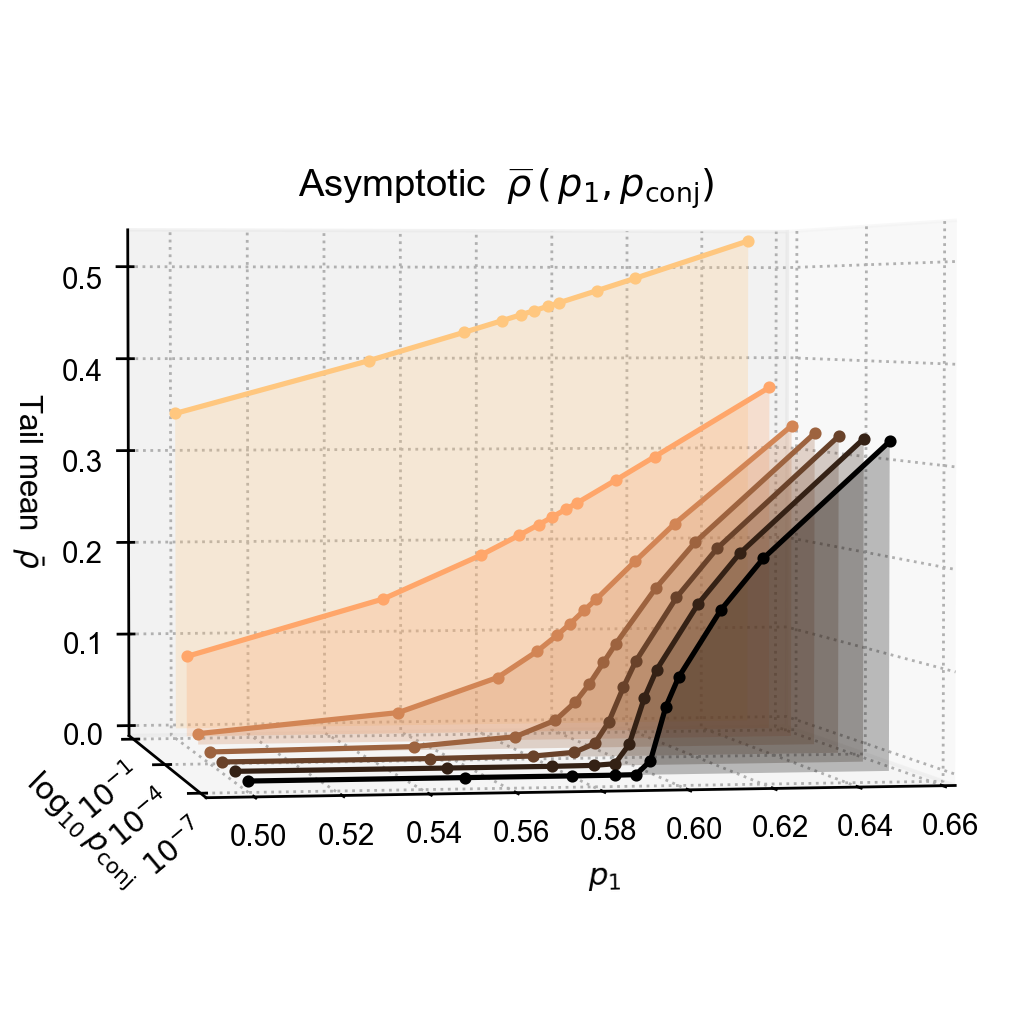

In [299]:
fig = viz.create_figure(fig_name="", fig_size=(6, 5,),)
axes = plt.axes(projection="3d", proj_type="persp",)
p_conj_choices = (1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,)
color_map_name = "copper_r"
color_map = plt.get_cmap(color_map_name)
colors = color_map(np.linspace(0, 1, len(p_conj_choices)))
for (p_conj, color, marker) in zip(reversed(p_conj_choices), colors, viz.markers.keys()):
    xyz = np.array([
        (v["p_1"], np.log10(v["p_conj"]), v["tail_mean_ρ"]) 
        for v in grouped_by_p3_expts[p_conj].values()
    ]).T
    xy0 = np.array([
        (v["p_1"], np.log10(v["p_conj"]), 0) for v in grouped_by_p3_expts[p_conj].values()
    ]).T
    axes.plot3D(
        *xyz, marker="o", ms=2.5, color=color, 
        label=r"$p_\mathsf{conj}=$"+rf"${p_conj:0.0e}$", zorder=100,
    )
    axes.fill_between(*xyz, *xy0, facecolors=color, alpha=0.25,)
plt.xlim(None, 0.663)
axes.xaxis._axinfo["grid"].update({"linestyle": ":"})
axes.yaxis._axinfo["grid"].update({"linestyle": ":"})
axes.zaxis._axinfo["grid"].update({"linestyle": ":"})
axes.set_box_aspect(None, zoom=1.15) 

axes.set_title(
    "Asymptotic  $\\widebar\\rho\\,(\\,p_1, p_\mathsf{conj})$", 
    fontdict={"fontsize": 11}, y=0.87,
)

axes.view_init(elev=2, azim=-100,)

axes.set_xlabel(r"$p_1$", fontdict={"fontsize": 9}, labelpad=-2,)
# axes.set_ylabel(r"$\log_{10}{p_conj}$", fontdict={"fontsize": 9}, labelpad=-3,)
axes.set_zlabel(r"Tail mean  $\bar{\rho}$", fontdict={"fontsize": 9}, labelpad=-1,)
axes.tick_params(axis="x", pad=-2,)
axes.tick_params(axis="y", pad=-3,)
axes.tick_params(axis="z", pad=1,)
axes.tick_params(axis='both', labelsize=8.5,)
plt.yticks(
    [-7, -4, -1], 
    [r"$10^{-7}$", r"$10^{-4}$", r"$10^{-1}$",], 
    rotation=40,
);
axes.text(
    0.54, -10, 0.8, r"$\log_{10}{p_\mathsf{conj}}$", zdir=(1,1,-4), 
    fontdict={"fontsize": 9}, transform=axes.transAxes,
);


### Percolation scaling

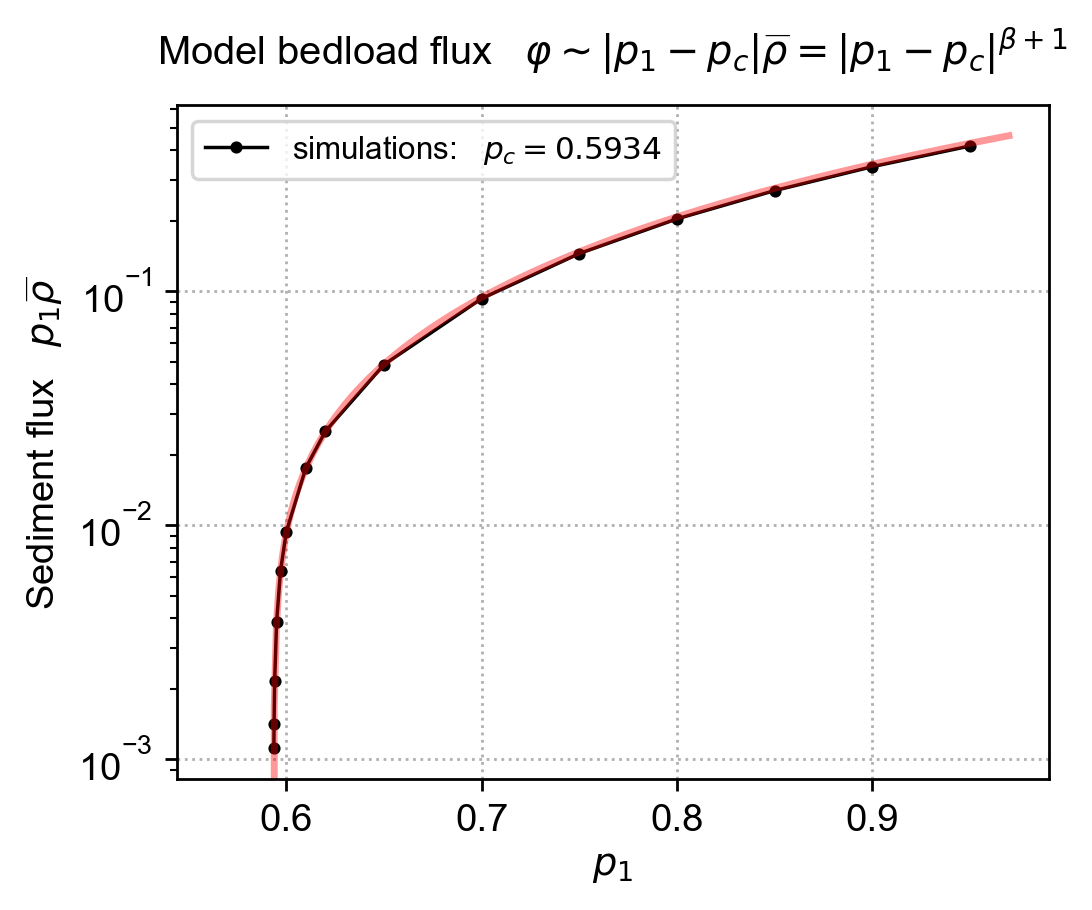

In [300]:
# group = grouped_by_model_b_expts
# p_c = 0.0499
# β = 0.5834
# ρ_scale = 1.69
# φ_scale = 4

group = grouped_by_percolation_expts
p_c = 0.5934
β = 0.5834
ρ_scale = 1.69
φ_scale = 4

fig = viz.create_figure(fig_name="", fig_size=(4.5, 3.5,),)

boost = 1
p_c_sub = 0
p_c_fake = 0.5
# p_c_sub = p_c
xy = np.array([
    (v["p_1"]-0., v["tail_mean_ρ"]*((v["p_1"]-p_c_fake)**boost)) 
    # (v["p_1"]-p_c_sub, v["tail_mean_ρ"]*(v["p_1"]**boost)) 
    for v in group.values()
]).T

plt.plot(*xy, "-ok", ms=2.5, lw=1, label=rf"simulations:   $p_c={p_c}$")

if p_c_sub==0:
    p_1 = np.linspace(0.56, 0.97)
    p_1 = 10**np.linspace(np.log10(0.56), np.log10(0.97), 301)
    x_label = r"$p_1$"
else:
    p_1 = 10**np.linspace(np.log10(1e-4), np.log10(4e-1), 301) + p_c_sub
    x_label = r"$p_1 - p_c$"
if boost==0:
    y_label = r"Tail mean  $\widebar{\rho}$"
    title = "Asymptotic  $\\widebar\\rho\\,(\\,p_1)$ scaling"
    model = r"$|p_1-p_c|^\beta$"
else:
    y_label = r"Sediment flux   $p_1\widebar{\rho}$"
    title = "Model bedload flux   $\\varphi \\sim |p_1-p_c| \\widebar\\rho = |p_1-p_c|^{\\beta+1}$"
    # title = "Model bedload flux   $\\varphi = p_1 \\widebar\\rho \\sim p_1^{\\beta+1}$"
    model = r"$p_1|p_1-p_c|^\beta$"

ρ_mean = ρ_scale * ((p_1-p_c)*np.heaviside(p_1-p_c,0))**β
φ_model = φ_scale * ((p_1-p_c)*np.heaviside(p_1-p_c,0))**(β+1)
φ_model = φ_scale * ((p_1-p_c)*np.heaviside(p_1-p_c,0))**β * (p_1-p_c_fake) /2.3
# φ_model = φ_scale * ((p_1-p_c)*np.heaviside(p_1-p_c,0))**(β)/4

# plt.plot(p_1-p_c_sub, ρ_mean*(p_1**boost), "-", lw=1.5, alpha=0.5, 
#     label=r"$\widebar{\rho}(p_1) \, \sim \,$"+f"{model}"+rf"    $\beta={β}$",
# )

plt.title(title, fontdict={"fontsize": 11.5}, y=1.03,)
plt.ylabel(y_label)
plt.xlabel(x_label)
plt.legend(fontsize=9)

plt.semilogy()
if boost==1:
    offset = 4
    plt.plot(p_1[offset:]-0., φ_model[offset:], "r", lw=2, alpha=0.4,)
# plt.loglog()
# plt.xlim(0, 1)
plt.grid(ls=":")

### Lattice evolution

In [301]:
viz_lattice = partial(
    viz.lattice,
    lattices=lattices, 
    p=parameters, 
    x=min(1000, parameters.n_x),
    y=min(1000, parameters.n_y),
    fig_size=(6, 4,),
)

In [302]:
i_slice: int
if n_lattices>0:
    for i_slice in (40,500): # 150, 200, 250,):
        name = make_name(parameters, "lattice", i_slice,)
        print(name)
        viz_lattice(
            name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
        )
        plt.show()

### Mean order parameter $t$-decay

ρmean_p0p650000_s6_nx300_ny300


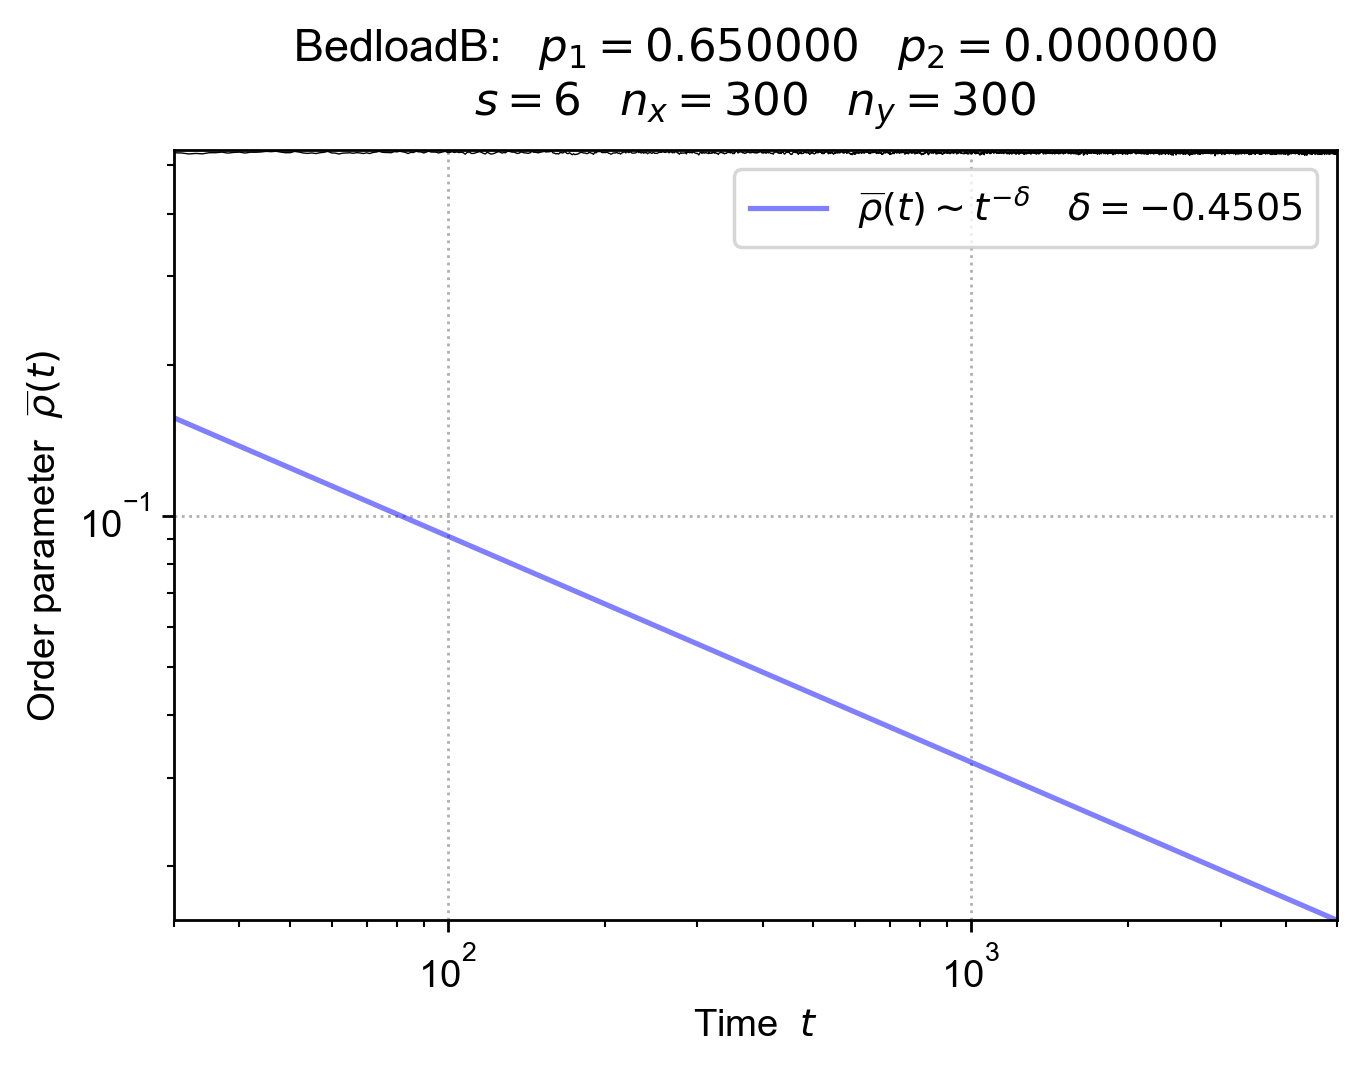

In [303]:
δ = 0.45051
scale = expt["scale"]
        
name = make_name(parameters, "ρmean", None, )
print(name)
viz.lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=30,
    do_ref_curve=True,
)
# plt.ylim(None, 1)
plt.show()

In [304]:
i_offset: int = parameters.n_iterations//5
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 1000.0-5000.0
Estimated t-decay exponent:  δ = 0.000


In [305]:
i_offset: int = parameters.n_iterations//4
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
mean_ρ_mean: float = np.mean(tracking["ρ_mean"][i_offset:])
print(f"t range: {t[0]}-{t[-1]}")
print(f"Tail mean: <ρ> = {(mean_ρ_mean):e}")
print(f"External:  p_conj = {(parameters.p_conj):g}")
print(f"Tail mean/p3:  <ρ>/p_conj = {round(mean_ρ_mean/parameters.p_conj, 1)}")

t range: 1250.0-5000.0
Tail mean: <ρ> = 5.290185e-01
External:  p_conj = 0.1
Tail mean/p3:  <ρ>/p_conj = 5.3


<hr>

## Export

In [306]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/bedload2d'